# 2-Stage -> Classify F or not, then A, B, C, or D

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from umap import UMAP

# Configuration
RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

In [5]:
df = pd.read_csv('../data/cleaned_yrbs_data.csv')
df.head()

,age,gender,education_level,ride_drinking_driver,school_safety_concern,threatened_at_school,fight_count,school_fight_count,neighborhood_violence,sexual_violence,...,parent_emotional_abuse,parent_physical_abuse,parent_abuse_parent,parent_uses_alcohol,parent_mental_illness,incarcerated_parent,have_friend,parent_monitoring,unfair_discipline_school,ADHD
0,15.0,Male,9th grade,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,3.0,4.0,0.0,1.0
1,16.0,Male,11th grade,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,1.0,0.0,0.0,1.0,3.0,3.0,0.0,0.0
2,17.0,Female,10th grade,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,1.0
3,14.0,Male,9th grade,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0
4,16.0,Male,9th grade,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,2.0,3.0,0.0,0.0,0.0,0.0,4.0,4.0,1.0,0.0


## Feature Engineering

In [7]:
# Health & Lifestyle
health_cols = ['hours_of_sleep', 'exercise', 'mental_health', 'ADHD']
df['health_score'] = df[health_cols].sum(axis=1)
df['health_risk'] = ((df['hours_of_sleep'] < 7) | (df['mental_health'] > 2) | (df['ADHD'] > 0)).astype(int)
df['sleep_exercise_interaction'] = df['hours_of_sleep'] * df['exercise']
df['mental_adhd_interaction'] = df['mental_health'] * df['ADHD']

# Alcohol Use
alcohol_cols = ['first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row']
df['alcohol_exposure'] = df[alcohol_cols].sum(axis=1)
df['alcohol_progression'] = df['alcohol_frequency'] - df['first_alcohol']
df['high_alcohol_use'] = ((df['alcohol_frequency'] > 0) | (df['hardcore_alcohol_frequency'] > 0)).astype(int)

# Family
family_cols = ['parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 
               'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'parent_monitoring']
df['family_adversity_score'] = df[family_cols[:-1]].sum(axis=1)
df['family_protective_score'] = df['parent_monitoring'] + df['have_friend']
df['family_risk_ratio'] = df['family_adversity_score'] / (df['family_protective_score'] + 1)

# School
school_cols = ['school_safety_concern', 'threatened_at_school', 'school_fight_count', 
               'school_racism', 'school_bullying', 'unfair_discipline_school']
df['school_stress_score'] = df[school_cols].sum(axis=1)
df['bullying_exposure'] = ((df['school_bullying'] > 0) | (df.get('cyber_bullying', pd.Series([0]*len(df))) > 0)).astype(int)
df['school_violence_index'] = df['school_safety_concern'] + df['threatened_at_school'] + df['school_fight_count']

# Social
df['social_engagement'] = df['social_media'] + df['have_friend']
df['social_risk'] = (df['social_media'] > 5).astype(int)
df['peer_support'] = df['have_friend']

# Violence
violence_cols = ['fight_count', 'neighborhood_violence', 'sexual_violence', 'ride_drinking_driver']
df['violence_exposure_score'] = df[violence_cols].sum(axis=1)
df['personal_violence'] = df['fight_count'] + df['sexual_violence']
df['environmental_violence'] = df['neighborhood_violence'] + df['ride_drinking_driver']

# Demographic
df['age_squared'] = df['age'] ** 2
df['adolescent_risk'] = ((df['age'] >= 14) & (df['age'] <= 17)).astype(int)
df['health_substance_risk'] = df['health_risk'] * df['high_alcohol_use']
df['family_school_stress'] = df['family_adversity_score'] * df['school_stress_score']
df['social_violence_link'] = df['social_risk'] * df['violence_exposure_score']

print(f"Original features: 34")
print(f"Total features: {df.shape[1]}")

Original features: 34
Total features: 59


## Preprocessing & Dimensionality Reduction

In [10]:
# Prepare features for preprocessing
X = df.drop(columns=['grade'])
y = df['grade'].astype(int)

# Define categorical and numeric features
categorical_features = ['gender', 'education_level', 'considered_suicide', 'sleep_place']
numeric_features = [col for col in X.columns if col not in categorical_features]

print(f"Categorical features: {len(categorical_features)}")
print(f"Numeric features: {len(numeric_features)}")

# Create preprocessor (StandardScaler + OneHotEncoder)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

X_preprocessed = preprocessor.fit_transform(X)
print(X_preprocessed.shape)

Categorical features: 4
Numeric features: 54
(15694, 74)


In [ ]:
# Apply UMAP
reducer = UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=RANDOM_STATE,
    verbose=0
)
umap_features = reducer.fit_transform(X_preprocessed)

# Combine with UMAP features
X_enhanced = np.hstack([X_preprocessed, umap_features])
print(f"{X_preprocessed.shape[1]}+2 = {X_enhanced.shape[1]}")

74 + 2 = 76


## Stage 1: Check if Grade F or passed

In [31]:
y_stage1 = (y == 0).astype(int)  # 1 if F, else 0
print(f"Passed (0): {(y_stage1 == 0).sum()}")
print(f"F (1): {(y_stage1 == 1).sum()}")
print(f"ratio: {(y_stage1 == 0).sum()/(y_stage1 == 1).sum():.3f}:1")

# Train-test split for Stage 1
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_enhanced, y_stage1, test_size=0.2, random_state=RANDOM_STATE, stratify=y_stage1)

print(f"\nTrain set: {X_train1.shape[0]:,}")
print(f"Test set: {X_test1.shape[0]:,}")

Passed (0): 15188
F (1): 506
ratio: 30.016:1

Train set: 12,555
Test set: 3,139


In [25]:
# Train Stage 1 model with SMOTE-like weights
check_F = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=5,
    scale_pos_weight=10,  # for F
    random_state=RANDOM_STATE,
    verbosity=0
)
check_F.fit(X_train1, y_train1)

# Evaluate Stage 1
y_pred_stage1_train = check_F.predict(X_train1)
y_pred_stage1_test = check_F.predict(X_test1)

train_acc_s1 = accuracy_score(y_train1, y_pred_stage1_train)
test_acc_s1 = accuracy_score(y_test1, y_pred_stage1_test)

print(f"Checking if grade F")
print(f"Train accuracy: {train_acc_s1:.4f}")
print(f"Test accuracy:  {test_acc_s1:.4f}")
print(classification_report(y_test1, y_pred_stage1_test, target_names=['Passed', 'F'], zero_division=0))

Checking if grade F
Train accuracy: 0.9892
Test accuracy:  0.9509
              precision    recall  f1-score   support

      Passed       0.97      0.98      0.97      3038
           F       0.18      0.15      0.16       101

    accuracy                           0.95      3139
   macro avg       0.58      0.56      0.57      3139
weighted avg       0.95      0.95      0.95      3139



## Stage 2: if passed, what Grade?

In [30]:
# Select only students who passed (grade>0)
pass_mask = (y>0)
X_pass = X_enhanced[pass_mask]

# Map grades 1-4 to 0-3 for Stage 2 classification
grade_4group_map = {1: 0, 2: 1, 3: 2, 4: 3}  # D, C, B, A
y_stage2_raw = y[pass_mask].map(grade_4group_map)

for grade_code, grade_name in enumerate(['D', 'C', 'B', 'A']):
    count = (y_stage2_raw == grade_code).sum()
    pct = count / len(y_stage2_raw) * 100
    print(f"{grade_name}: {count:,} ({pct:.1f}%)")

# Train-test split for Stage 2
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_pass, y_stage2_raw, test_size=0.2, random_state=RANDOM_STATE, stratify=y_stage2_raw
)

print(f"\nTrain set: {X_train2.shape[0]:,}")
print(f"Test set: {X_test2.shape[0]:,}")

D: 842 (5.5%)
C: 2,667 (17.6%)
B: 5,094 (33.5%)
A: 6,585 (43.4%)

Train set: 12,150
Test set: 3,038


In [34]:
# Train Stage 2 model
model_stage2 = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=4,
    objective='multi:softprob',
    num_class=4,
    random_state=RANDOM_STATE,
    verbosity=0
)
model_stage2.fit(X_train2, y_train2)

y_pred_stage2_train = model_stage2.predict(X_train2)
y_pred_stage2_test = model_stage2.predict(X_test2)

train_acc_s2 = accuracy_score(y_train2, y_pred_stage2_train)
test_acc_s2 = accuracy_score(y_test2, y_pred_stage2_test)

print(f"A/B/C/D")
print(f"Train accuracy: {train_acc_s2:.4f}")
print(f"Test accuracy:  {test_acc_s2:.4f}")
print(classification_report(y_test2, y_pred_stage2_test, target_names=['D', 'C', 'B', 'A'], zero_division=0))

A/B/C/D
Train accuracy: 0.6087
Test accuracy:  0.4480
              precision    recall  f1-score   support

           D       0.11      0.01      0.02       168
           C       0.34      0.12      0.18       534
           B       0.35      0.32      0.33      1019
           A       0.51      0.74      0.60      1317

    accuracy                           0.45      3038
   macro avg       0.33      0.30      0.28      3038
weighted avg       0.40      0.45      0.40      3038



## Combine Stages

In [39]:
# Hybrid inference: Combine Stage 1 and Stage 2
final_preds = []
stage1_preds_test = check_F.predict(X_test1)

for i in range(len(stage1_preds_test)):
    if stage1_preds_test[i] == 1:  # Predicted F
        final_preds.append(0)
    else:  # Predicted to pass, use Stage 2
        sample = X_test1[i].reshape(1, -1)
        stage2_pred = model_stage2.predict(sample)[0]
        final_preds.append(stage2_pred + 1)  # Remap to 1-4

y_actual_test = y[y_test1.index].values
full_acc = accuracy_score(y_actual_test, final_preds)

print(f"full")
print(f"Overall Accuracy (2-Stages): {full_acc:.4f}")
print(classification_report(y_actual_test, final_preds, target_names=['F', 'D', 'C', 'B', 'A'], zero_division=0))

full
Overall Accuracy (2-Stages): 0.5511
              precision    recall  f1-score   support

           F       0.18      0.15      0.16       101
           D       0.78      0.15      0.26       188
           C       0.63      0.28      0.39       530
           B       0.50      0.46      0.48       996
           A       0.58      0.82      0.68      1324

    accuracy                           0.55      3139
   macro avg       0.53      0.37      0.39      3139
weighted avg       0.56      0.55      0.52      3139



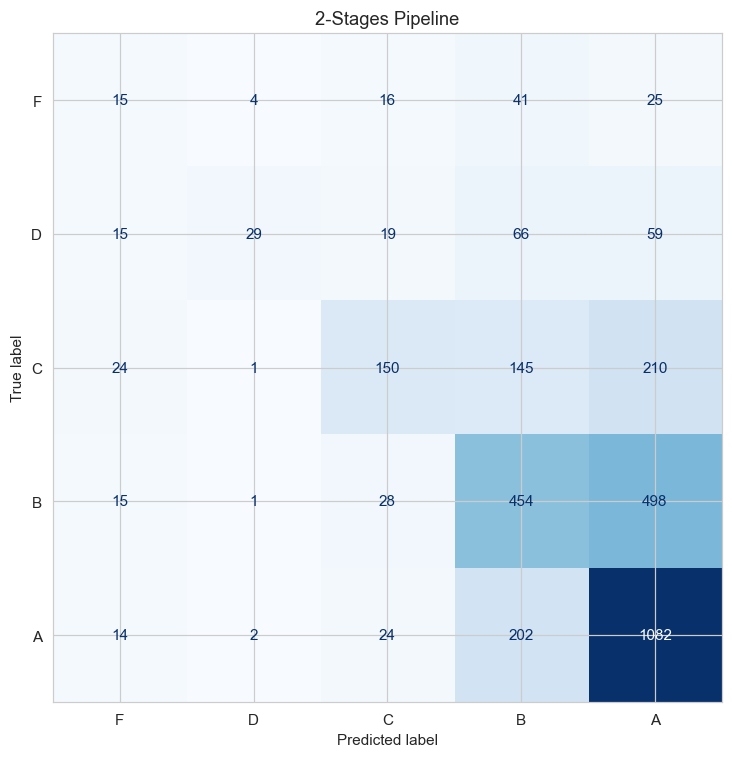

In [42]:
# Confusion matrix for hybrid pipeline
cm_hybrid = confusion_matrix(y_actual_test, final_preds)
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix=cm_hybrid,
    display_labels=['F', 'D', 'C', 'B', 'A'],
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('2-Stages Pipeline')
plt.tight_layout()
plt.show()

                               Feature  Importance
                        hours_of_sleep    0.049074
                         feel_hopeless    0.032758
                 neighborhood_violence    0.031171
sleep_place_Home of parent or gaurdian    0.027526
                   sleep_place_unknown    0.026968
                 considered_suicide_No    0.026798
                    school_fight_count    0.024729
             education_level_9th grade    0.024137
                           health_risk    0.022893
            sleep_exercise_interaction    0.022544
                 school_violence_index    0.021706
               violence_exposure_score    0.020965
                           gender_Male    0.020592
                   school_stress_score    0.019204
                         mental_health    0.017927


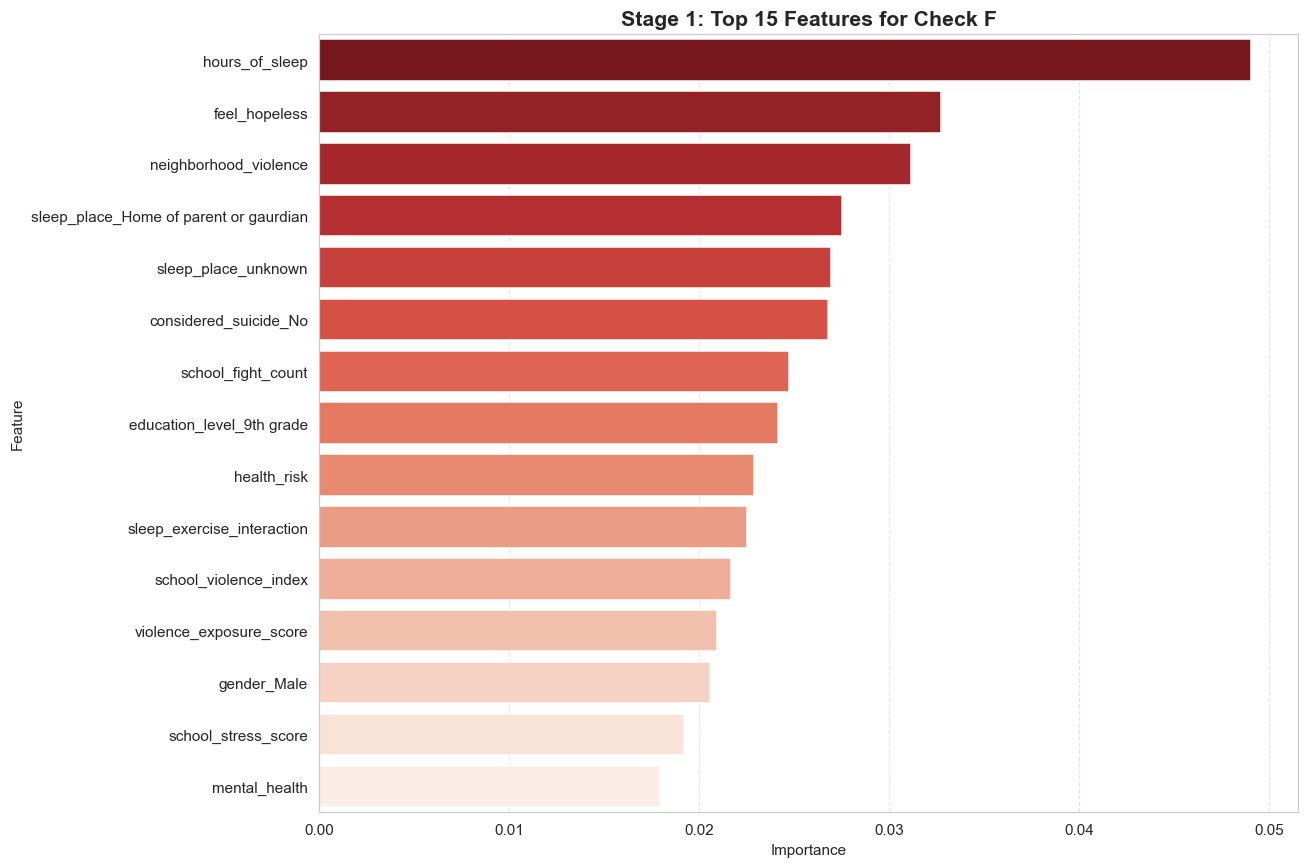

In [51]:
num_names = numeric_features
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_names + cat_names + ['UMAP_1', 'UMAP_2']

# Get importances
importances_s1 = check_F.feature_importances_

if len(all_feature_names) == len(importances_s1):
    feat_import_s1_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances_s1
    }).sort_values(by='Importance', ascending=False)

    print(feat_import_s1_df.head(15).to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feat_import_s1_df.head(15), palette='Reds_r', ax=ax)
    ax.set_title('Stage 1: Top 15 Features for Check F', fontsize=14, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠ Feature dimension mismatch: {len(all_feature_names)} names vs {len(importances_s1)} importances")

                   Feature  Importance
               health_risk    0.069024
               gender_Male    0.041927
             gender_Female    0.034648
             feel_hopeless    0.028170
               fight_count    0.026026
                      ADHD    0.025785
           adolescent_risk    0.021371
            hours_of_sleep    0.019813
       incarcerated_parent    0.019321
   violence_exposure_score    0.018589
sleep_exercise_interaction    0.017927
     school_violence_index    0.017281
     considered_suicide_No    0.016372
         bullying_exposure    0.016225
education_level_12th grade    0.015236


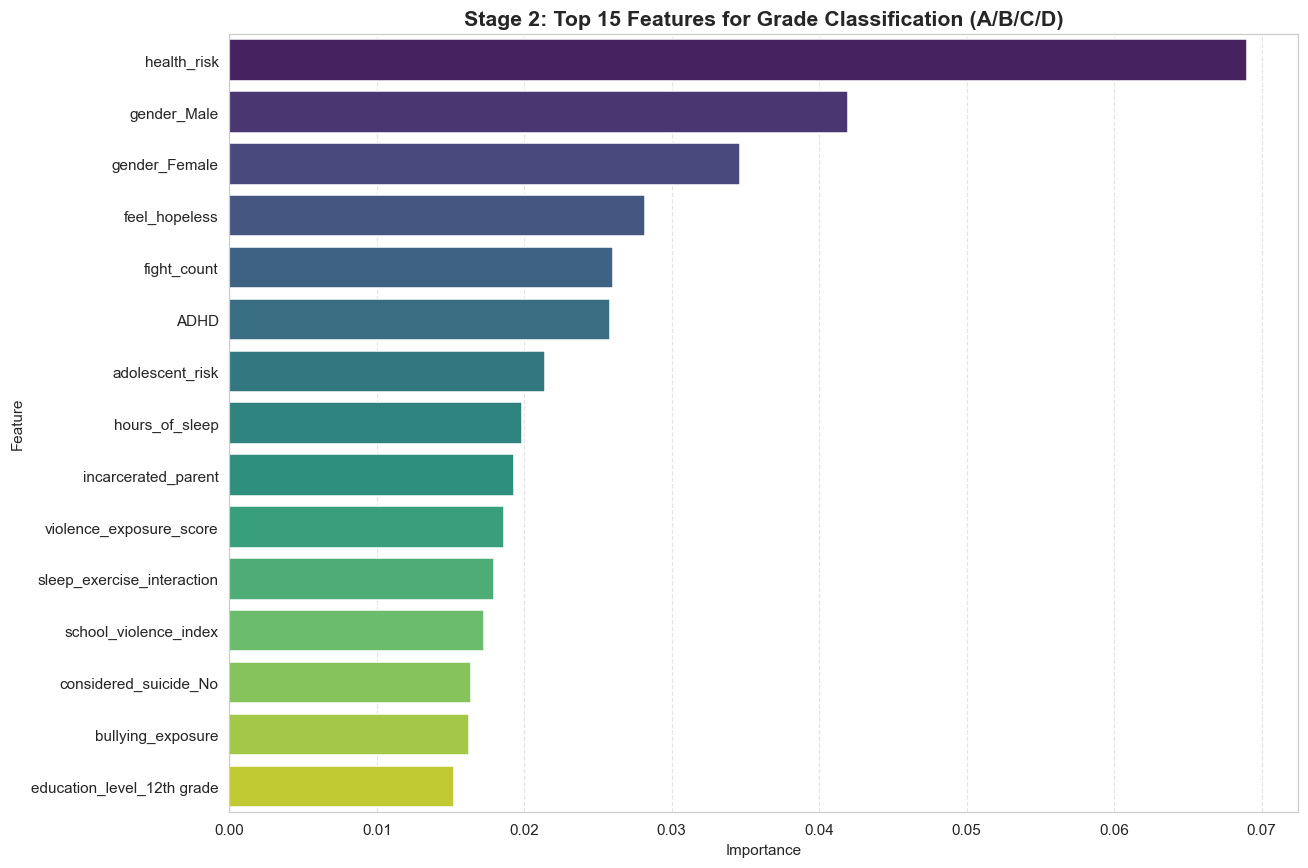

In [52]:
# Stage 2 Feature Importance (Grade Classifier)
importances_s2 = model_stage2.feature_importances_

if len(all_feature_names) == len(importances_s2):
    feat_import_s2_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances_s2
    }).sort_values(by='Importance', ascending=False)

    print(feat_import_s2_df.head(15).to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feat_import_s2_df.head(15), palette='viridis', ax=ax)
    ax.set_title('Stage 2: Top 15 Features for Grade Classification (A/B/C/D)', fontsize=14, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠ Feature dimension mismatch: {len(all_feature_names)} names vs {len(importances_s2)} importances")